## Ejercicio 1: Evaluación de solicitud de credito bancario

### Ficha PEAS


| Elemento | Descripcion |
|-----------|-----------|
| **Percepcion (S)**| Ingreso_mensual (S/.), monto_solicitado (S/.), tiene_historial_moroso (True/False). |
| **Acciones (A)** |  Aprobar, aprobar con condiciones, rechazar. |
| **Entorno (E)** | Sistema de evaluación crediticia de un banco; recibe solicitudes de clientes con datos declarados/consultados en el momento de la solicitud. |
| **Objetivo** | Minimizar el riesgo de incumplimiento de pago sin rechazar innecesariamente solicitudes viables. |
| **Medida de desempeño (P)** | Tasa de aprobaciones que sí se pagan, tasa de rechazos que efectivamente evitaban mora, monto total de pérdidas evitadas, número de clientes buenos rechazados por error. |


### Justificación de las reglas

Se usa la relación monto_solicitado / ingreso_mensual porque es el indicador estándar de capacidad de pago en la banca es: entre más alta, mayor compromiso del ingreso del cliente con esa deuda. El umbral de 0.3 separa un endeudamiento bajo de uno moderado y el umbral de 0.5 marca el punto donde el banco considera el riesgo demasiado alto para aprobar sin condiciones. El historial moroso se combina con la relación en vez de evaluarse solo porque un cliente con buena relación de ingreso/monto pero con un historial de no pagar sigue siendo más riesgoso que uno sin historial por eso baja de nivel su resultado.

### Código

In [1]:
def agente_credito(ingreso_mensual, monto_solicitado, tiene_historial_moroso):
    #Define la funcion que recibe los 3 datos que percibe el agente segun la ficha PEAS
    
    relacion = monto_solicitado / ingreso_mensual
    # Calcula que porcentaje del ingreso mensual representa el monto pedido
        
    if relacion <= 0.3:
    # Entra aqui si el monto pedido es bajo comparado con el ingreso.
        
        if not tiene_historial_moroso:
             # Si no tiene historial moroso, considera al cliente que tiene un buen historial
            return "aprobar", "relacion monto/ingreso baja (<=0.3) y sin historial moroso"
            # Retorna aprobar directo
        else:
        # Aqui entra la condicion, SI tiene un historial de moroso
            return "aprobar con condiciones", "relacion monto/ingreso baja (<=0.3) pero con historial moroso"
            # Aunque la relacion es buena, el historial baja un nivel la decision de dar el credito.
    elif relacion <= 0.5:
        # Si no cayo en el primer if, entra aqui cuando la relacion esta entre 0.3 y 0.5 con un riesgo moderado.
        if not tiene_historial_moroso:
            return "aprobar con condiciones", "relacion monto/ingreso moderada (0.3-0.5) sin historial moroso"
            # Riesgo moderado sin historial moroso, se aprueba pero con condiciones
        else:
            return "rechazar", "relacion monto/ingreso moderada (0.3-0.5) con historial moroso"
            # Riesgo moderado + historial moroso combinados ya es demasiado riesgo y se rechaza
    else:
         # Si no entro en ninguno de los casos anteriores, la relacion es mayor a 0.5 con riesgo alto
        return "rechazar", "relacion monto/ingreso mayor a 0.5, riesgo demasiado alto"
        # Se rechaza sin importar el historial, porque el monto pedido ya es demasiado alto para el ingreso que tiene.

### Simulación y pruebas

In [4]:
casos = [
    # (ingreso_mensual, monto_solicitado, tiene_historial_moroso)
    (3000, 600, False),    # relacion = 0.20 -> aprobar
    (3000, 600, True),     # relacion = 0.20 -> aprobar con condiciones
    (3000, 1200, False),   # relacion = 0.40 -> aprobar con condiciones
    (3000, 1200, True),    # relacion = 0.40 -> rechazar
    (2000, 1000, False),   # relacion = 0.50 -> caso limite: aprobar con condiciones
    (1000, 800, False),    # relacion = 0.80 -> rechazar
]

for ingreso, monto, moroso in casos:
    accion, motivo = agente_credito(ingreso, monto, moroso)
    relacion = monto / ingreso
    print(f"Ingreso={ingreso}, Monto={monto}, Moroso={moroso}, Relacion={relacion:.3f}")
    print(f"Accion: {accion} | Motivo: {motivo}\n")

Ingreso=3000, Monto=600, Moroso=False, Relacion=0.200
Accion: aprobar | Motivo: relacion monto/ingreso baja (<=0.3) y sin historial moroso

Ingreso=3000, Monto=600, Moroso=True, Relacion=0.200
Accion: aprobar con condiciones | Motivo: relacion monto/ingreso baja (<=0.3) pero con historial moroso

Ingreso=3000, Monto=1200, Moroso=False, Relacion=0.400
Accion: aprobar con condiciones | Motivo: relacion monto/ingreso moderada (0.3-0.5) sin historial moroso

Ingreso=3000, Monto=1200, Moroso=True, Relacion=0.400
Accion: rechazar | Motivo: relacion monto/ingreso moderada (0.3-0.5) con historial moroso

Ingreso=2000, Monto=1000, Moroso=False, Relacion=0.500
Accion: aprobar con condiciones | Motivo: relacion monto/ingreso moderada (0.3-0.5) sin historial moroso

Ingreso=1000, Monto=800, Moroso=False, Relacion=0.800
Accion: rechazar | Motivo: relacion monto/ingreso mayor a 0.5, riesgo demasiado alto



### Visualización

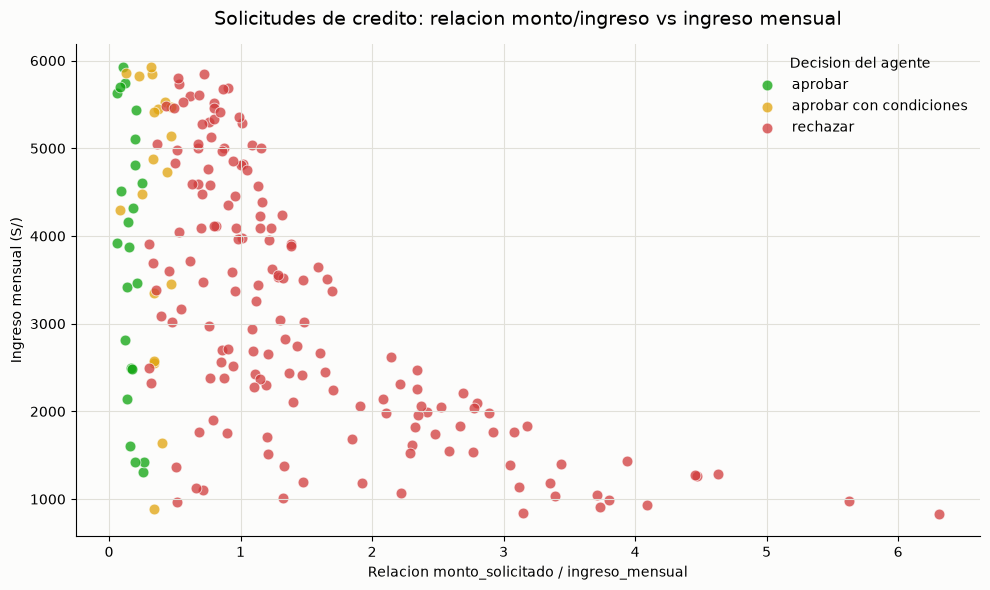

aprobar: 23 solicitudes
aprobar con condiciones: 19 solicitudes
rechazar: 158 solicitudes


In [7]:
import numpy as np
import matplotlib.pyplot as plt
# Importamos numpy para generar numeros aleatorios y matplotlib para graficar

np.random.seed(42)
# Fija una "semilla" para que los numeros aleatorios sean siempre los mismos cada vez que se ejecute la celda

n = 200
# Cantidad de solicitudes que se va simular

ingreso_mensual = np.random.uniform(800, 6000, n)
# Genera 200 ingresos aleatorios, cada uno entre S/.800 y S/.6000

monto_solicitado = np.random.uniform(200, 6000, n)
# Genera 200 montos solicitados aleatorios, cada uno entre S/.200 y S/.6000

tiene_historial_moroso = np.random.rand(n) < 0.3
# Genera 200 valores True/False
# np.random.rand(n) da numeros entre 0 y 1; si el numero es menor a 0.3, es True

solicitudes = []
# Lista vacia donde iremos guardando el resultado de cada solicitud

for i in range(n):
    # Recorre las 200 solicitudes generadas, una por una

    accion, _ = agente_credito(ingreso_mensual[i], monto_solicitado[i], tiene_historial_moroso[i])
    # Le pasamos los 3 datos de la solicitud i a nuestra funcion y guardamos solo la accion
    # (el guion bajo _ significa que ignoramos el "motivo", aqui no lo necesitamos)

    relacion = monto_solicitado[i] / ingreso_mensual[i]
    # Calculamos la relacion de esa solicitud, para usarla en el grafico

    solicitudes.append((relacion, ingreso_mensual[i], accion))
    # Guardamos los 3 datos que necesitamos graficar: relacion, ingreso y la decision tomada

colores = {
    "aprobar": "#0ca30c",               # verde
    "aprobar con condiciones": "#e0a30c", # amarillo/naranja
    "rechazar": "#d03b3b",              # rojo
}
# Diccionario que asocia cada posible decision con un color para el grafico

fig, ax = plt.subplots(figsize=(10, 6), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
# Crea la figura y el area del grafico con un color de fondo claro

for accion in colores:
    # Recorre las 3 posibles acciones (aprobar, aprobar con condiciones, rechazar)

    puntos = [(r, ing) for (r, ing, a) in solicitudes if a == accion]
    # De todas las solicitudes, filtra solo las que tuvieron esta accion en particular

    if puntos:
        # Si hay al menos una solicitud con esta accion, la graficamos

        rel = [p[0] for p in puntos]
        ing = [p[1] for p in puntos]
        # Separamos las relaciones y los ingresos en dos listas distintas

        ax.scatter(rel, ing, s=60, alpha=0.75, c=colores[accion],
                   edgecolors="white", linewidths=0.6, label=accion)
        # Dibuja los puntos de esta accion en el grafico con su color correspondiente

ax.set_title("Solicitudes de credito: relacion monto/ingreso vs ingreso mensual", fontsize=14, pad=14)
ax.set_xlabel("Relacion monto_solicitado / ingreso_mensual")
ax.set_ylabel("Ingreso mensual (S/)")
# Agrega titulo y nombres de los ejes

ax.grid(True, color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
# Agrega una cuadricula suave y quita los bordes superior/derecho del grafico

ax.legend(title="Decision del agente", frameon=False, loc="upper right")
# Muestra la leyenda que indica que color corresponde a cada decision

plt.tight_layout()
plt.show()
# Ajusta el espaciado y muestra el grafico final

for accion in colores:
    total = sum(1 for (_, _, a) in solicitudes if a == accion)
    print(f"{accion}: {total} solicitudes")
# Al final, imprime cuantas de las 200 solicitudes cayeron en cada categoria